# mamba_va (CompSSM) — local eval monitor

Run this on the **laptop** while Colab trains `train_mamba_va_nocond.ipynb`.
Reads checkpoints, `hparams.json`, and the CSV metrics log from the Google
Drive-synced `mamba_va_runs/` folder.

The model predicts **wet audio** directly (dry→wet). For comparison with the
GR-prediction LSTM in [`03_initial_GR_pred/eval_lstm.ipynb`](../03_initial_GR_pred/eval_lstm.ipynb)
this notebook **derives gain-reduction curves post-hoc** from the moving RMS of
dry / target-wet / predicted-wet (1024-sample window, same `src.dsp_torch` helper)
and plots them in the **same 3-panel layout** (dry waveform / GR dB target-vs-pred
/ GR error dB).

1. List all `CompSSM` runs + their checkpoints
2. Plot train-vs-val loss from `metrics.csv`
3. Stream any checkpoint over validation songs → GR curves + listenable audio
4. Chunked validation audio metrics (ESR, MR-STFT, …) — same table schema as the GR eval

No Colab resources are used — purely reads files synced by Google Drive.

> Note: since mamba_va v0.2 the level detector runs through the parallel scan
> (no per-sample loop), so CPU/MPS streaming is fast.

> Sanity floor: a constant ≈ −10 dB gain scores ESR ≈ 0.075/0.090 on the val
> songs (Borderline / NosPalpitants) — a checkpoint has only learned dynamics
> once it is clearly below that.

> Requirements: `uv sync` at repo root.

> ⚠ Checkpoints trained with mamba_va **v0.1** (runs before 2026-06-10) use a
> different detector parameterisation and will not load into v0.2 code.

In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────
import os, sys, glob, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# Reuse the GR-eval helpers (run listing, pairing, split, metric aggregation).
_HELPERS_DIR = Path.cwd().parent / "03_initial_GR_pred"
assert (_HELPERS_DIR / "eval_helpers.py").is_file(), f"eval_helpers not at {_HELPERS_DIR}"
sys.path.insert(0, str(_HELPERS_DIR))
from eval_helpers import (
    _checkpoint_sort_key, latest_best_checkpoint, list_runs, plot_loss_curves,
    _find_hparams_json, same_setting_pairs, _read_dry_wet_segment,
    _pair_num_frames, _song_from_dry_path, _validation_pairs_from_training_split,
    _weighted_average_metric_rows,
)

# Make the mamba_va package importable (local source tree, not a pip package).
def _local_pkg_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for c in (base / "mamba_va", base / "04_s6_ssm" / "mamba_va"):
            if (c / "mamba_va" / "__init__.py").is_file():
                return c
    return None

_pkg_root = _local_pkg_root()
assert _pkg_root, "mamba_va package not found under the repo."
sys.path.insert(0, str(_pkg_root))
import mamba_va
from mamba_va import CompSSM
from src.losses import compute_all_losses as compute_audio_losses
from src.dsp_torch import (
    GR_DB_MIN, GR_DB_MAX, RMS_WINDOW,
    compute_gr_target_norm, gr_norm_to_db,
)

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR  = "/Volumes/Saola's Drive/AllCode/thesis/data/mamba_va_runs"

SAMPLE_RATE = 44100
DEVICE = "cpu"   # custom scan/detector are torch-native; 'mps' also works

print(f"torch {torch.__version__}  |  device: {DEVICE}  |  RMS window: {RMS_WINDOW}")
print(f"mamba_va {mamba_va.__version__} from {Path(mamba_va.__file__).parent}")

torch 2.10.0  |  device: cpu  |  RMS window: 1024
mamba_va 0.2.0 from /Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/04_s6_ssm/mamba_va/mamba_va


In [2]:
# ── 1. List available CompSSM runs ──────────────────────────────────
assert RUNS_DIR and os.path.isdir(RUNS_DIR), f"RUNS_DIR not found: {RUNS_DIR}"

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, "No runs found yet."

available_models_df = runs_df[runs_df["type"].str.contains("CompSSM", na=False)].copy()
assert not available_models_df.empty, "No CompSSM (mamba_va) runs found."

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available CompSSM runs: {len(available_models_df)}")
display(available_models_df[display_cols])

Available CompSSM runs: 7


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
0,mamba_va_20260604_155155_mamba_va_nocond_tbptt,mamba_va.CompSSM,NaN,NaN,0,None,2026-06-10 10:07:22.318715096
1,mamba_va_20260604_154300_mamba_va_nocond_tbptt,mamba_va.CompSSM,NaN,NaN,0,None,2026-06-10 10:07:22.384739876
2,mamba_va_20260604_160654_mamba_va_nocond_tbptt,mamba_va.CompSSM,12.0,1.535808,6,best-012-624.ckpt,2026-06-10 10:07:22.451186895
3,mamba_va_20260610_100842_mamba_va_nocond_tbptt,mamba_va.CompSSM,NaN,NaN,0,None,2026-06-10 10:09:09.227109909
4,mamba_va_20260610_102856_mamba_va_nocond_tbptt,mamba_va.CompSSM,NaN,NaN,0,None,2026-06-10 10:29:24.276188850
5,mamba_va_20260610_105119_mamba_va_nocond_tbptt,mamba_va.CompSSM,NaN,NaN,0,None,2026-06-10 10:51:30.775391340
6,mamba_va_20260610_110429_mamba_va_nocond_tbptt,mamba_va.CompSSM,33.0,1.238594,10,best-024-800.ckpt,2026-06-10 11:10:50.956952810


In [3]:
# ── 2. Select run and checkpoint ───────────────────────────────────
# Leave SELECTED_RUN_NAME = None to auto-pick the most recently modified run.
SELECTED_RUN_NAME = None

if SELECTED_RUN_NAME is None:
    selected_run = available_models_df.iloc[-1]
else:
    matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
    assert len(matches) == 1, f"Run not found among CompSSM runs: {SELECTED_RUN_NAME}"
    selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

print(f"Selected run   : {RUN_NAME}")
print(f"Model type     : {selected_run['type']}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")

Selected run   : mamba_va_20260610_110429_mamba_va_nocond_tbptt
Model type     : mamba_va.CompSSM
Eval checkpoint: best-024-800.ckpt
Best val loss  : 1.238594


In [4]:
# ── 2b. Inspect checkpoints ───────────────────────────────────────
print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<32}  {sz:6.2f} MB{marker}")

Selected run   : mamba_va_20260610_110429_mamba_va_nocond_tbptt
Eval checkpoint: best-024-800.ckpt
Checkpoints    :
  last.ckpt                           0.32 MB
  epoch-004.ckpt                      0.32 MB
  epoch-009.ckpt                      0.32 MB
  best-011-384.ckpt                   0.32 MB
  epoch-014.ckpt                      0.32 MB
  epoch-019.ckpt                      0.32 MB
  best-023-768.ckpt                   0.32 MB
  epoch-024.ckpt                      0.32 MB
  best-024-800.ckpt                   0.32 MB <-- eval
  epoch-029.ckpt                      0.32 MB


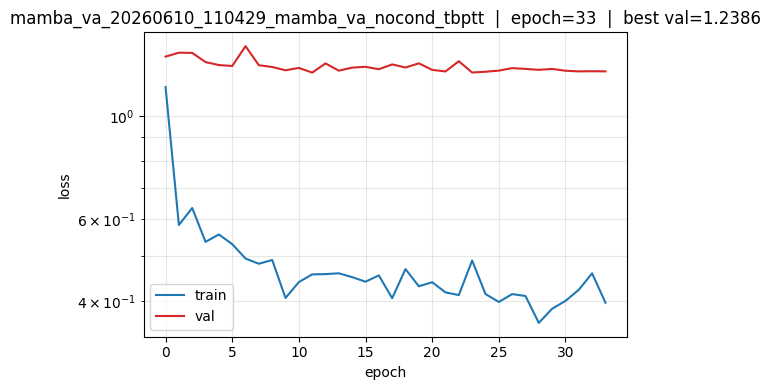

In [5]:
# ── 3. Loss curves ───────────────────────────────────────────
_ = plot_loss_curves(RUN_DIR)

In [6]:
# ── 4. Checkpoint loading + streaming render ──────────────────────────
# CompSSM is a plain nn.Module wrapped by the Lightning `CompSSMSystem` at train
# time (weights live under the `model.` prefix in the checkpoint).  We rebuild
# the bare CompSSM from hparams.json and load the stripped state_dict — no need
# to import the Lightning system here.

def load_compssm_from_ckpt(ckpt_path: str, hparams_path: str | None = None):
    if hparams_path is None:
        hparams_path = _find_hparams_json(ckpt_path)
    assert hparams_path and os.path.isfile(hparams_path), (
        f"hparams.json not found near {ckpt_path}")
    with open(hparams_path) as f:
        hp = json.load(f)

    c = hp["compssm"]
    model = CompSSM(
        n_params=c["n_params"], d_model=c["d_model"], d_state=c["d_state"],
        n_layers=c["n_layers"], expand=c["expand"], conv_kernel=c["conv_kernel"],
        n_bands=c["n_bands"], max_db=c["max_db"],
        sr=c.get("sr", hp.get("sample_rate", 44100)),
    )

    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    sd = ckpt.get("state_dict", ckpt)
    model_sd = {k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")}
    missing, unexpected = model.load_state_dict(model_sd, strict=False)
    if missing or unexpected:
        print(f"[warning] load_state_dict: {len(missing)} missing, {len(unexpected)} unexpected")
    model.to(DEVICE).eval()
    return model, hp


# Internal streaming block size.  Larger blocks = far fewer forwards on CPU
# (1 s blocks are correct but very slow for whole-song eval).
STREAM_CHUNK = 131072   # ~3 s at 44.1 kHz


@torch.no_grad()
def stream_render(
    model,
    u: torch.Tensor,
    chunk: int | None = None,
    parallel: bool = True,
):
    """Stream (1, L) dry audio through the stateful model, carrying state across
    `chunk`-sized windows.  Equivalent to a single causal pass; parallel=True
    uses the fast associative scan within each chunk."""
    chunk = STREAM_CHUNK if chunk is None else chunk
    u = u.to(DEVICE)
    state, outs = None, []
    n = u.shape[-1]
    for s in range(0, n, chunk):
        y, state = model(u[:, s:s + chunk], state=state, parallel=parallel)
        outs.append(y)
    return torch.cat(outs, dim=1)


@torch.no_grad()
def predict_full_song_wet(
    model,
    dry_path: str,
    wet_path: str,
    sr: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """One causal pass over the full song; returns (pred, wet) as [T] CPU tensors."""
    total = _pair_num_frames(dry_path, wet_path, sr)
    dry, wet = _read_dry_wet_segment(dry_path, wet_path, 0, total, sr)
    pred = stream_render(model, dry).squeeze(0).float().cpu()
    return pred, wet.squeeze(0).cpu()


print("Loader ready: load_compssm_from_ckpt(), stream_render(), predict_full_song_wet()")

Loader ready: load_compssm_from_ckpt(), stream_render()


In [7]:
# ── 5. GR-curve evaluation & visualisation (RMS-derived, mirrors eval_lstm) ──
#
# CompSSM predicts wet audio directly. To compare with the GR-prediction LSTM we
# derive gain reduction post-hoc from the moving RMS of dry / target / predicted:
#   GR(t) = 20*log10(rms(out)) - 20*log10(rms(dry))
# using the same 1024-sample helper as 03_initial_GR_pred/eval_lstm.ipynb.

from IPython.display import Audio, display


@torch.no_grad()
def _predict_wet_segment(
    model,
    dry_context: torch.Tensor,
    context_offset: int,
    target_len: int,
) -> torch.Tensor:
    """Stream dry_context through the stateful model and return the aligned wet chunk."""
    u = dry_context if dry_context.ndim == 2 else dry_context.unsqueeze(0)
    pred_context = stream_render(model, u).squeeze(0)
    start = context_offset
    stop = context_offset + target_len
    return pred_context[..., start:stop].float().cpu()


@torch.no_grad()
def predict_gr_curves(
    ckpt_path: str,
    dry_wav_path: str,
    wet_wav_path: str,
    start_sec: float = 0.0,
    duration_sec: float = 6.0,
    hparams_path: str | None = None,
    pre_roll_sec: float = 1.0,
    rms_window: int = RMS_WINDOW,
):
    model, hp = load_compssm_from_ckpt(ckpt_path, hparams_path)
    sr = int(hp["sample_rate"])
    rms_win = int(hp.get("rms_window", rms_window))

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    pre_roll = int(round(pre_roll_sec * sr))
    context_start = max(0, start - pre_roll)
    context_offset = start - context_start

    dry_ctx, wet_ctx = _read_dry_wet_segment(
        dry_wav_path, wet_wav_path, context_start, stop, sr,
    )
    n = min(
        stop - start,
        dry_ctx.shape[-1] - context_offset,
        wet_ctx.shape[-1] - context_offset,
    )
    assert n > 0
    w = slice(context_offset, context_offset + n)

    pred_ctx = _predict_wet_segment(model, dry_ctx, 0, dry_ctx.shape[-1])
    dry = dry_ctx[..., w]
    wet = wet_ctx[..., w]
    pred = pred_ctx[..., w]

    gr_true = gr_norm_to_db(compute_gr_target_norm(dry, wet, rms_win)).squeeze().cpu().numpy()
    gr_pred = gr_norm_to_db(compute_gr_target_norm(dry, pred, rms_win)).squeeze().cpu().numpy()
    err = gr_pred - gr_true
    audio_losses = compute_audio_losses(pred.unsqueeze(0), wet.unsqueeze(0))
    song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")

    return {
        "song": song,
        "setting": hp["setting"],
        "model_type": hp.get("model_type", "mamba_va.CompSSM"),
        "ckpt": ckpt_path,
        "sample_rate": sr,
        "start_sec": start_sec,
        "duration_sec": n / sr,
        "pre_roll_sec": context_offset / sr,
        "time": np.arange(n) / sr,
        "dry": dry.squeeze().cpu().numpy(),
        "gr_true": gr_true,
        "gr_pred": gr_pred,
        "error": err,
        "mae_db": float(np.mean(np.abs(err))),
        "rmse_db": float(np.sqrt(np.mean(err ** 2))),
        "audio_esr": float(audio_losses["ESR"]),
        "hparams": hp,
    }


@torch.no_grad()
def visualize_prediction(
    ckpt_path: str,
    dry_wav_path: str | None = None,
    wet_wav_path: str | None = None,
    start_sec: float = 0.0,
    duration_sec: float = 6.0,
    hparams_path: str | None = None,
    pre_roll_sec: float = 1.0,
    rms_window: int = RMS_WINDOW,
    title: str | None = None,
):
    _, hp = load_compssm_from_ckpt(ckpt_path, hparams_path)
    setting = hp["setting"]
    pairs = same_setting_pairs(DATA_ROOT, setting)
    if dry_wav_path is None:
        dry_wav_path, wet_wav_path = pairs[0]
    elif wet_wav_path is None:
        song = os.path.basename(dry_wav_path).replace("_UnmasteredWAV.wav", "")
        wet_wav_path = os.path.join(
            DATA_ROOT, "processed_ground_truth", setting, f"{song}-exported.wav",
        )

    curves = predict_gr_curves(
        ckpt_path=ckpt_path,
        dry_wav_path=dry_wav_path,
        wet_wav_path=wet_wav_path,
        start_sec=start_sec,
        duration_sec=duration_sec,
        hparams_path=hparams_path,
        pre_roll_sec=pre_roll_sec,
        rms_window=rms_window,
    )

    t = curves["time"]
    fig, axes = plt.subplots(
        3, 1, figsize=(11, 7), sharex=True,
        gridspec_kw={"height_ratios": [1, 2, 1]},
    )
    axes[0].plot(t, curves["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry")
    axes[0].set_ylim(-1.05, 1.05)
    axes[0].grid(alpha=0.3)

    axes[1].plot(t, curves["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[1].plot(t, curves["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[1].set_ylabel("Gain reduction (dB)")
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)

    axes[2].plot(t, curves["error"], lw=0.8, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("error (dB)")
    axes[2].set_xlabel("time (s)")
    axes[2].grid(alpha=0.3)

    ttl = title or (
        f"{curves['song']}  |  CompSSM (GR derived)  |  {curves['setting']}\n"
        f"ckpt={os.path.basename(ckpt_path)}  "
        f"pre-roll={curves['pre_roll_sec']:.2f}s  "
        f"MAE={curves['mae_db']:.2f} dB  RMSE={curves['rmse_db']:.2f} dB  "
        f"audio ESR={curves['audio_esr']:.4f}"
    )
    fig.suptitle(ttl, fontsize=10)
    plt.tight_layout()
    plt.show()
    return curves


def compare_same_setting_curves(
    ckpt_path: str,
    start_sec: float = 30.0,
    duration_sec: float = 5.0,
    max_pairs: int = 2,
    start_pair: int = 5,
    hparams_path: str | None = None,
    pre_roll_sec: float = 1.0,
):
    _, hp = load_compssm_from_ckpt(ckpt_path, hparams_path)
    pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
    selected = pairs[start_pair:max_pairs + start_pair]
    print(f"Comparing {len(selected)} of {len(pairs)} pairs — CompSSM model")
    return [
        visualize_prediction(
            ckpt_path=ckpt_path,
            dry_wav_path=d,
            wet_wav_path=w,
            start_sec=start_sec,
            duration_sec=duration_sec,
            hparams_path=hparams_path,
            pre_roll_sec=pre_roll_sec,
        )
        for d, w in selected
    ]


def listen_excerpt(curves: dict, which: str = "pred"):
    """Play dry / target-wet / predicted-wet for the plotted excerpt."""
    sr = int(curves["sample_rate"])
    dry = curves["dry"]
    # Reconstruct target/pred wet from dry + GR for listening (approximate phase).
    gr_true_t = torch.from_numpy(curves["gr_true"]).float()
    gr_pred_t = torch.from_numpy(curves["gr_pred"]).float()
    dry_t = torch.from_numpy(dry).float()
    target = (dry_t * torch.pow(10.0, gr_true_t / 20.0)).numpy()
    pred = (dry_t * torch.pow(10.0, gr_pred_t / 20.0)).numpy()
    print(f"Listen — {curves['song']}:  dry / target / predicted")
    display(Audio(dry, rate=sr))
    display(Audio(target, rate=sr))
    display(Audio(pred, rate=sr))


print("Eval functions ready: predict_gr_curves(), visualize_prediction(), compare_same_setting_curves()")

Eval functions ready: predict_gr_curves(), visualize_prediction(), compare_same_setting_curves()


## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then optionally set `SELECTED_RUN_NAME` in
the run-selection cell (or leave it `None` for the newest run).

Running best-024-800.ckpt


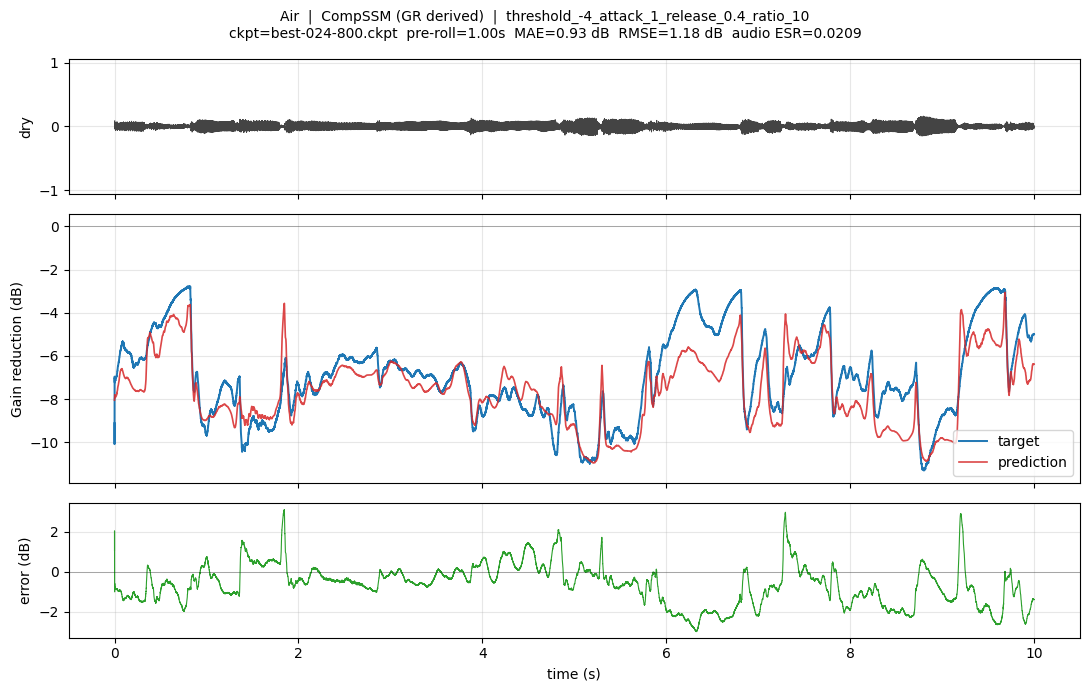

In [8]:
# Single prediction preview
print(f"Running {os.path.basename(EVAL_CKPT_PATH)}")

preview_curves = visualize_prediction(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=30.0,
    duration_sec=10.0,
)

Comparing 3 of 10 pairs — CompSSM model


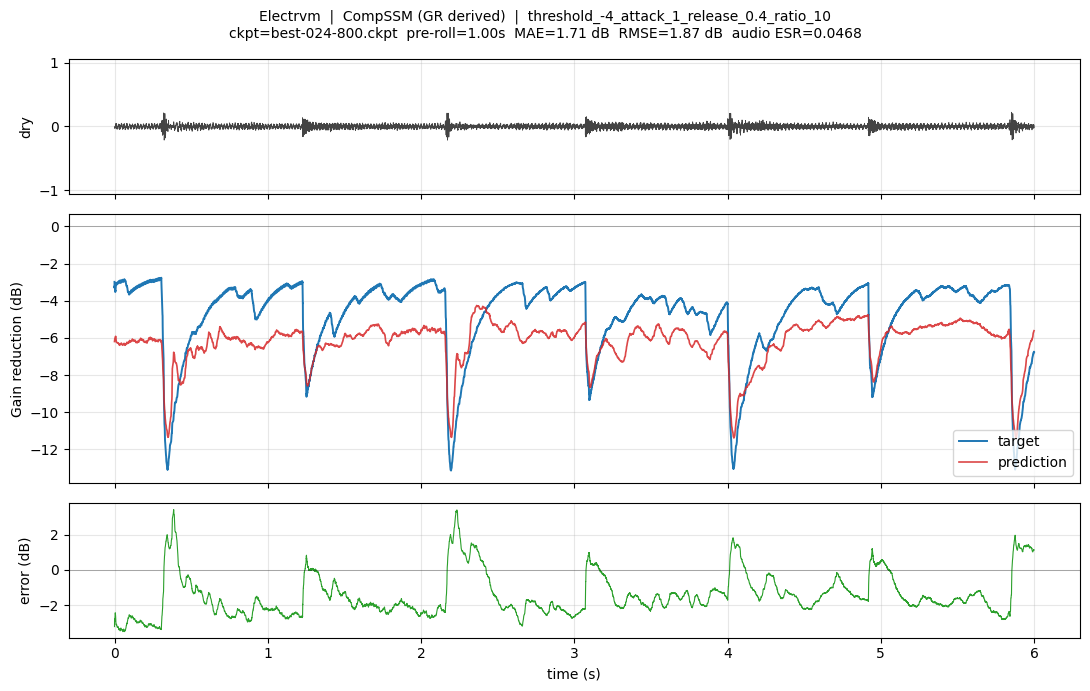

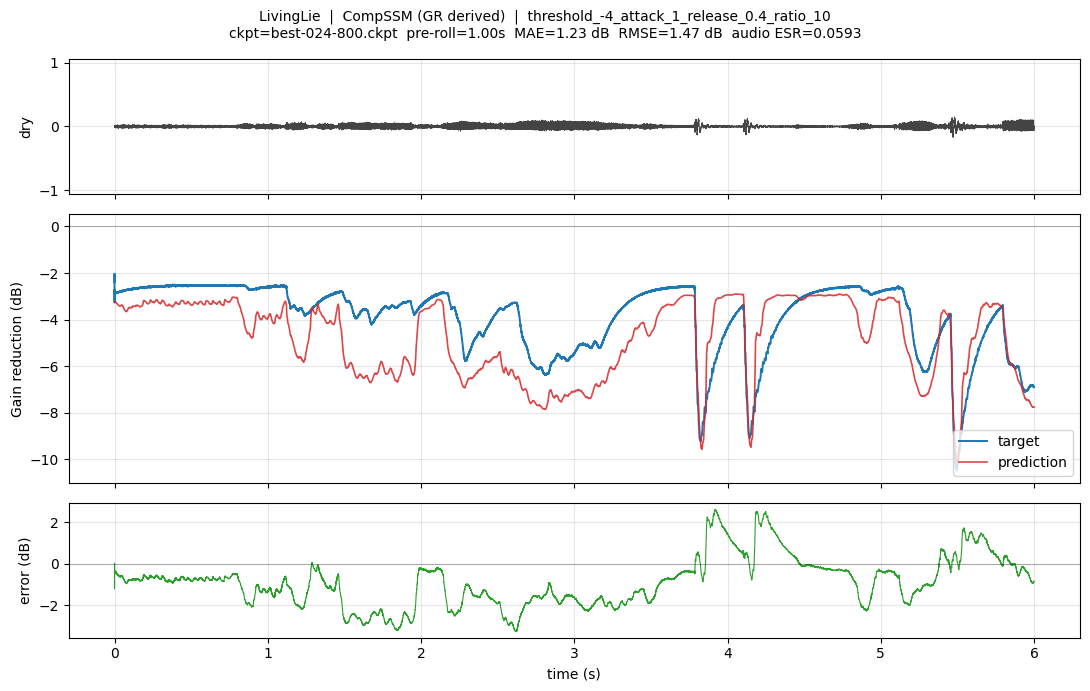

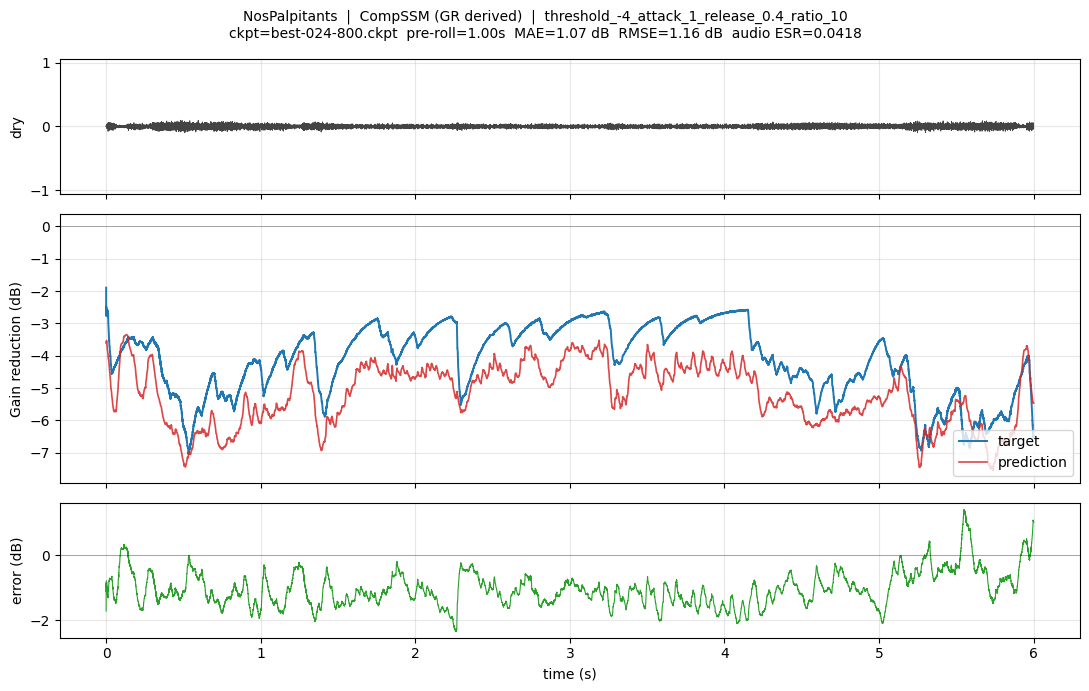

Listen — Air:  dry / target / predicted


In [9]:
# Compare across multiple songs
results = compare_same_setting_curves(
    ckpt_path=EVAL_CKPT_PATH,
    start_sec=20.0,
    duration_sec=6.0,
    max_pairs=3,
)

# Optional: listen to the single-song preview from the cell above
listen_excerpt(preview_curves)

In [10]:
# Validation-set reconstructed audio metrics (chunked, memory-friendly)
#
# Reconstructs the same song-level validation split used during training,
# streams predicted wet audio in chunks, scores each chunk with
# src.losses.compute_all_losses, then reports one duration-weighted validation row.
# Same table schema as 03_initial_GR_pred/eval_lstm.ipynb.

import gc

# Leave as None to evaluate the full validation split. Use a small integer for
# a quick smoke test, or list validation song names for a subset.
MAX_VALIDATION_SONGS: int | None = None
EVAL_VALIDATION_SONGS: list[str] | None = None

# Smaller chunks reduce peak memory. Increase if you want faster evaluation and
# have RAM/VRAM headroom.
WHOLE_SONG_CHUNK_SEC = 10.0
WHOLE_SONG_PRE_ROLL_SEC = 1.0
SAVE_CHUNK_METRICS = False

model, hp = load_compssm_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
sr = int(hp["sample_rate"])
device = torch.device(DEVICE)
chunk_frames = int(round(WHOLE_SONG_CHUNK_SEC * sr))
pre_roll_frames = int(round(WHOLE_SONG_PRE_ROLL_SEC * sr))
metric_cols = ["MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]

all_pairs = same_setting_pairs(DATA_ROOT, hp["setting"])
eval_pairs = _validation_pairs_from_training_split(all_pairs, hp)

if EVAL_VALIDATION_SONGS is not None:
    selected_names = set(EVAL_VALIDATION_SONGS)
    eval_pairs = [
        (dry_path, wet_path)
        for dry_path, wet_path in eval_pairs
        if _song_from_dry_path(dry_path) in selected_names
    ]

if MAX_VALIDATION_SONGS is not None:
    eval_pairs = eval_pairs[:MAX_VALIDATION_SONGS]

assert eval_pairs, "No validation pairs selected for evaluation."

validation_chunk_rows = []
for song_idx, (dry_path, wet_path) in enumerate(eval_pairs, start=1):
    song = _song_from_dry_path(dry_path)
    total_frames = _pair_num_frames(dry_path, wet_path, sr)
    print(
        f"[{song_idx}/{len(eval_pairs)}] Evaluating validation song {song} "
        f"({total_frames / sr:.1f}s, chunks of {WHOLE_SONG_CHUNK_SEC:.1f}s)"
    )

    for chunk_idx, start in enumerate(range(0, total_frames, chunk_frames), start=1):
        stop = min(start + chunk_frames, total_frames)
        context_start = max(0, start - pre_roll_frames)
        context_offset = start - context_start

        dry_context, wet_context = _read_dry_wet_segment(
            dry_path,
            wet_path,
            context_start,
            stop,
            sr,
        )
        target_len = min(
            stop - start,
            dry_context.shape[-1] - context_offset,
            wet_context.shape[-1] - context_offset,
        )
        if target_len <= 0:
            continue

        wet_chunk = wet_context[..., context_offset : context_offset + target_len]
        pred_chunk = _predict_wet_segment(
            model,
            dry_context,
            context_offset,
            target_len,
        )

        losses = compute_audio_losses(pred_chunk.unsqueeze(0), wet_chunk.unsqueeze(0))
        validation_chunk_rows.append({
            "Song": song,
            "Chunk": chunk_idx,
            "Start (s)": start / sr,
            "Duration (s)": target_len / sr,
            "Frames": target_len,
            **losses,
        })

        del dry_context, wet_context, wet_chunk, pred_chunk
        if device.type == "cuda":
            torch.cuda.empty_cache()

    gc.collect()

assert validation_chunk_rows, "No validation chunks were evaluated."

weighted_metrics = _weighted_average_metric_rows(validation_chunk_rows, metric_cols)
total_frames = sum(row["Frames"] for row in validation_chunk_rows)
validation_metrics_df = pd.DataFrame([
    {
        "Split": "validation",
        "Songs": len(eval_pairs),
        "Chunks": len(validation_chunk_rows),
        "Duration (s)": total_frames / sr,
        **weighted_metrics,
    }
])

validation_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation.csv"
validation_metrics_df.to_csv(validation_metrics_path, index=False)
print(f"Saved validation audio metrics -> {validation_metrics_path}")

if SAVE_CHUNK_METRICS:
    chunk_metrics_path = Path(RUN_DIR) / "eval_audio_metrics_validation_chunks.csv"
    pd.DataFrame(validation_chunk_rows).to_csv(chunk_metrics_path, index=False)
    print(f"Saved validation chunk audio metrics -> {chunk_metrics_path}")

display(validation_metrics_df)

Validation split: 2 validation songs, 8 train songs (seed=42, train_split=0.8)
Validation songs: ['Borderline', 'NosPalpitants']
[1/2] Evaluating validation song Borderline (273.9s, chunks of 10.0s)


KeyboardInterrupt: 